In [1]:
# Imports and GPU setup
import os
import torch
import numpy as np
import pandas as pd
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

# GPU Settings
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
torch.cuda.empty_cache()

print("All imports done!")
print(f"GPU available: {torch.cuda.is_available()}")
print(f"GPU name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

All imports done!
GPU available: True
GPU name: Tesla T4


In [ ]:
import os

# Kaggle dataset path
for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/thedevastator/extended-stanford-natural-language-inference-dat/validation.csv
/kaggle/input/datasets/thedevastator/extended-stanford-natural-language-inference-dat/train.csv
/kaggle/input/datasets/thedevastator/extended-stanford-natural-language-inference-dat/test.csv


In [ ]:
# Load dataset
DATA_PATH = "/kaggle/input/datasets/thedevastator/extended-stanford-natural-language-inference-dat"

train_df = pd.read_csv(f"{DATA_PATH}/train.csv")
val_df   = pd.read_csv(f"{DATA_PATH}/validation.csv")
test_df  = pd.read_csv(f"{DATA_PATH}/test.csv")

# Map integer labels to strings
label_map_int = {0: "entailment", 1: "neutral", 2: "contradiction"}
for df in [train_df, val_df, test_df]:
    df["label_str"] = df["label"].map(label_map_int)
    df.dropna(subset=["premise", "hypothesis", "label_str"], inplace=True)

# Subsample exactly 100K with fixed seed. Must match across all variants
train_df = train_df.sample(n=100_000, random_state=42).reset_index(drop=True)

print(f"Train: {len(train_df)}")
print(f"Val:   {len(val_df)}")
print(f"Test:  {len(test_df)}")
print(f"Label distribution:\n{train_df['label_str'].value_counts()}")

Train: 100000
Val:   9842
Test:  9824
Label distribution:
label_str
entailment       33523
neutral          33330
contradiction    33147
Name: count, dtype: int64


In [4]:
MODEL_NAME = "microsoft/deberta-v3-base"

label2id = {"entailment": 0, "neutral": 1, "contradiction": 2}
id2label  = {0: "entailment", 1: "neutral", 2: "contradiction"}

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer loaded!")

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

Tokenizer loaded!


In [5]:
class NLIDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=256):
        self.encodings = tokenizer(
            df["premise"].tolist(),
            df["hypothesis"].tolist(),
            truncation=True,
            max_length=max_length,
            padding="max_length"
        )
        self.labels = [label2id[l] for l in df["label_str"].tolist()]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }
        item["labels"] = torch.tensor(self.labels[idx])
        return item

train_dataset = NLIDataset(train_df, tokenizer, max_length=256)
val_dataset   = NLIDataset(val_df,   tokenizer, max_length=256)
test_dataset  = NLIDataset(test_df,  tokenizer, max_length=256)

print(f"Train dataset: {len(train_dataset)}")
print(f"Val dataset:   {len(val_dataset)}")
print(f"Test dataset:  {len(test_dataset)}")

Train dataset: 100000
Val dataset:   9842
Test dataset:  9824


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    label2id=label2id,
    id2label=id2label
)
model = model.float()

print("Model loaded")
print(f"Parameters: {model.num_parameters():,}")

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
classifier.bias                         | MISSING    | 
pooler.dense.bias                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.weight        

Model loaded!
Parameters: 184,424,451


In [ ]:
# Training arguments
training_args = TrainingArguments(
    output_dir                  = "/kaggle/working/variant_a",
    num_train_epochs            = 3,
    per_device_train_batch_size = 8,
    gradient_accumulation_steps = 4,
    per_device_eval_batch_size  = 32,
    learning_rate               = 2e-5,
    weight_decay                = 0.01,
    warmup_steps                = 3090,
    fp16                        = True,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    save_total_limit            = 3,
    load_best_model_at_end      = True,
    metric_for_best_model       = "accuracy",
    greater_is_better           = True,
    dataloader_num_workers      = 0,
    logging_steps               = 100,
    report_to                   = "none"
)
print("Training args ready.")

Training args ready!


In [ ]:
# Cell 7 — Accuracy metric
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = (predictions == labels).mean()
    return {"accuracy": accuracy}

print("Metrics ready.")

Metrics ready!


In [ ]:
# Full training
torch.cuda.empty_cache()

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    label2id=label2id,
    id2label=id2label
)
model = model.float()

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = val_dataset,
    compute_metrics = compute_metrics,
)

print("Starting Variant A full training")
print("Expected time: ~1.5 hours on T4\n")

trainer.train()

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
classifier.bias                         | MISSING    | 
pooler.dense.bias                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.weight        

Starting Variant A full training...
Expected time: ~1.5 hours on T4



/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy
1,5.842915,1.228083,0.751372
2,4.454660,1.007160,0.801768
3,3.772406,0.854361,0.840886


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

TrainOutput(global_step=4689, training_loss=5.405065899745415, metrics={'train_runtime': 11909.388, 'train_samples_per_second': 25.19, 'train_steps_per_second': 0.394, 'total_flos': 3.9467720448e+16, 'train_loss': 5.405065899745415, 'epoch': 3.0})

In [11]:
# Save model permanently to Kaggle Output
import os

SAVE_PATH = "/kaggle/working/variant_a_final_model"
os.makedirs(SAVE_PATH, exist_ok=True)

trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print("Model saved to:", SAVE_PATH)
print("Saved files:")
for f in os.listdir(SAVE_PATH):
    size = os.path.getsize(f"{SAVE_PATH}/{f}")
    print(f"  {f} — {size/1024/1024:.1f} MB")
print("To load this model:")
print("  model = AutoModelForSequenceClassification.from_pretrained(path)")
print("  tokenizer = AutoTokenizer.from_pretrained(path)")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /kaggle/working/variant_a_final_model
Saved files:
  model.safetensors — 703.5 MB
  training_args.bin — 0.0 MB
  tokenizer_config.json — 0.0 MB
  tokenizer.json — 8.0 MB
  config.json — 0.0 MB
To load this model:
  model = AutoModelForSequenceClassification.from_pretrained(path)
  tokenizer = AutoTokenizer.from_pretrained(path)


In [ ]:
import pickle
import os
import json

# Save pickle file
print("Save pickle file")
with open("/kaggle/working/variant_a_model.pkl", "wb") as f:
    pickle.dump(model, f)
print(f"Pickle saved! Size: {os.path.getsize('/kaggle/working/variant_a_model.pkl')/1024/1024:.1f} MB")

# Save full model folder 
print("Saving full model")
trainer.save_model("/kaggle/working/variant_a_final_model")
tokenizer.save_pretrained("/kaggle/working/variant_a_final_model")
print("Full model saved!")

Save pickle file
Pickle saved! Size: 703.6 MB
Save config.json
Config saved.
Saving full model


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Full model saved!


OSError: [Errno 28] No space left on device

In [20]:
# Per-label accuracy horizontal bar plot
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

predictions_output = trainer.predict(test_dataset)
preds = np.argmax(predictions_output.predictions, axis=-1)
true_labels = predictions_output.label_ids

label_names = ["Entailment", "Neutral", "Contradiction"]
label_correct = defaultdict(int)
label_total = defaultdict(int)

for pred, true in zip(preds, true_labels):
    label_total[true] += 1
    if pred == true:
        label_correct[true] += 1

per_label_acc = {
    label_names[i]: round(label_correct[i] / label_total[i] * 100, 2)
    for i in range(3)
}

print("Per-label accuracy:")
for label, acc in per_label_acc.items():
    print(f"  {label:15s}: {acc}%")

fig, ax = plt.subplots(figsize=(10, 4))
labels     = list(per_label_acc.keys())
accuracies = list(per_label_acc.values())
colors     = ["#4CAF50", "#2196F3", "#FF5722"]

bars = ax.barh(labels, accuracies, color=colors,
               edgecolor="white", height=0.4)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{acc}%", va="center", fontsize=12, fontweight="bold")

ax.set_xlabel("Accuracy (%)")
ax.set_title("Variant A — Per-Label Accuracy on e-SNLI Test Set",
             fontweight="bold", fontsize=13)
ax.set_xlim(0, 110)
ax.axvline(x=83.36, color="black", linestyle="--",
           linewidth=1.5, label="Overall accuracy (83.36%)")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig("/kaggle/working/variant_a_per_label_accuracy.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Per-label plot saved!")


KeyboardInterrupt: 

In [ ]:
from datasets import load_dataset

def make_dataset(premises, hypotheses, labels, tokenizer, max_length=256):
    # Convert to lists
    premises   = list(premises)
    hypotheses = list(hypotheses)
    labels     = list(labels)
    
    class SimpleNLI(Dataset):
        def __init__(self):
            self.enc = tokenizer(
                premises, hypotheses,
                truncation=True, max_length=max_length,
                padding="max_length"
            )
            self.labels = labels
        def __len__(self): return len(self.labels)
        def __getitem__(self, i):
            item = {k: torch.tensor(v[i]) for k, v in self.enc.items()}
            item["labels"] = torch.tensor(self.labels[i])
            return item
    return SimpleNLI()

cross_results = {}

# SNLI test
print("Loading SNLI")
snli = load_dataset("stanfordnlp/snli", split="test")
snli = snli.filter(lambda x: x["label"] != -1)
snli_ds = make_dataset(snli["premise"], snli["hypothesis"], snli["label"], tokenizer)
r = trainer.evaluate(snli_ds)
cross_results["SNLI Test"] = round(r["eval_accuracy"], 4)
print(f"SNLI Test: {cross_results['SNLI Test']:.4f}")

# MultiNLI
print("Loading MultiNLI")
mnli = load_dataset("nyu-mll/multi_nli")
mnli_m_ds = make_dataset(
    mnli["validation_matched"]["premise"],
    mnli["validation_matched"]["hypothesis"],
    mnli["validation_matched"]["label"], tokenizer
)
mnli_mm_ds = make_dataset(
    mnli["validation_mismatched"]["premise"],
    mnli["validation_mismatched"]["hypothesis"],
    mnli["validation_mismatched"]["label"], tokenizer
)
r = trainer.evaluate(mnli_m_ds)
cross_results["MultiNLI Matched"] = round(r["eval_accuracy"], 4)
print(f"MultiNLI Matched: {cross_results['MultiNLI Matched']:.4f}")

r = trainer.evaluate(mnli_mm_ds)
cross_results["MultiNLI Mismatched"] = round(r["eval_accuracy"], 4)
print(f"MultiNLI Mismatched: {cross_results['MultiNLI Mismatched']:.4f}")

# ANLI
print("Loading ANLI")
anli = load_dataset("facebook/anli")
for rd in ["r1", "r2", "r3"]:
    split = anli[f"test_{rd}"]
    ds = make_dataset(split["premise"], split["hypothesis"], split["label"], tokenizer)
    r = trainer.evaluate(ds)
    cross_results[f"ANLI {rd.upper()}"] = round(r["eval_accuracy"], 4)
    print(f"ANLI {rd.upper()}: {cross_results[f'ANLI {rd.upper()}']:.4f}")

print("\nFULL CROSS-DOMAIN RESULTS")
for k, v in cross_results.items():
    print(f"{k:30s}: {v*100:.2f}%")

Loading SNLI...


README.md: 0.00B [00:00, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/412k [00:00<?, ?B/s]

plain_text/validation-00000-of-00001.par(…):   0%|          | 0.00/413k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/19.6M [00:00<?, ?B/s]

...

Generating test_r2 split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating train_r3 split:   0%|          | 0/100459 [00:00<?, ? examples/s]

Generating dev_r3 split:   0%|          | 0/1200 [00:00<?, ? examples/s]

Generating test_r3 split:   0%|          | 0/1200 [00:00<?, ? examples/s]

ANLI R1: 0.3080
ANLI R2: 0.3150
ANLI R3: 0.3167

=== FULL CROSS-DOMAIN RESULTS ===
SNLI Test                     : 83.35%
MultiNLI Matched              : 59.10%
MultiNLI Mismatched           : 62.03%
ANLI R1                       : 30.80%
ANLI R2                       : 31.50%
ANLI R3                       : 31.67%


In [ ]:
import json
import os

all_results = {
    "variant": "A",
    "model": "microsoft/deberta-v3-base",
    "epochs": 3,
    "train_samples": 100000,
    "val_accuracy": 0.8409,
    "val_loss": 0.8544,
    "test_accuracy": 0.8335,
    "SNLI Test": 0.8335,
    "MultiNLI Matched": 0.5910,
    "MultiNLI Mismatched": 0.6203,
    "ANLI R1": 0.3080,
    "ANLI R2": 0.3150,
    "ANLI R3": 0.3167
}

with open("/kaggle/working/variant_a_full_results.json", "w") as f:
    json.dump(all_results, f, indent=2)

print("Results saved!")
print(json.dumps(all_results, indent=2))

Results saved!
{
  "variant": "A",
  "model": "microsoft/deberta-v3-base",
  "epochs": 3,
  "train_samples": 100000,
  "val_accuracy": 0.8409,
  "val_loss": 0.8544,
  "test_accuracy": 0.8335,
  "SNLI Test": 0.8335,
  "MultiNLI Matched": 0.591,
  "MultiNLI Mismatched": 0.6203,
  "ANLI R1": 0.308,
  "ANLI R2": 0.315,
  "ANLI R3": 0.3167
}


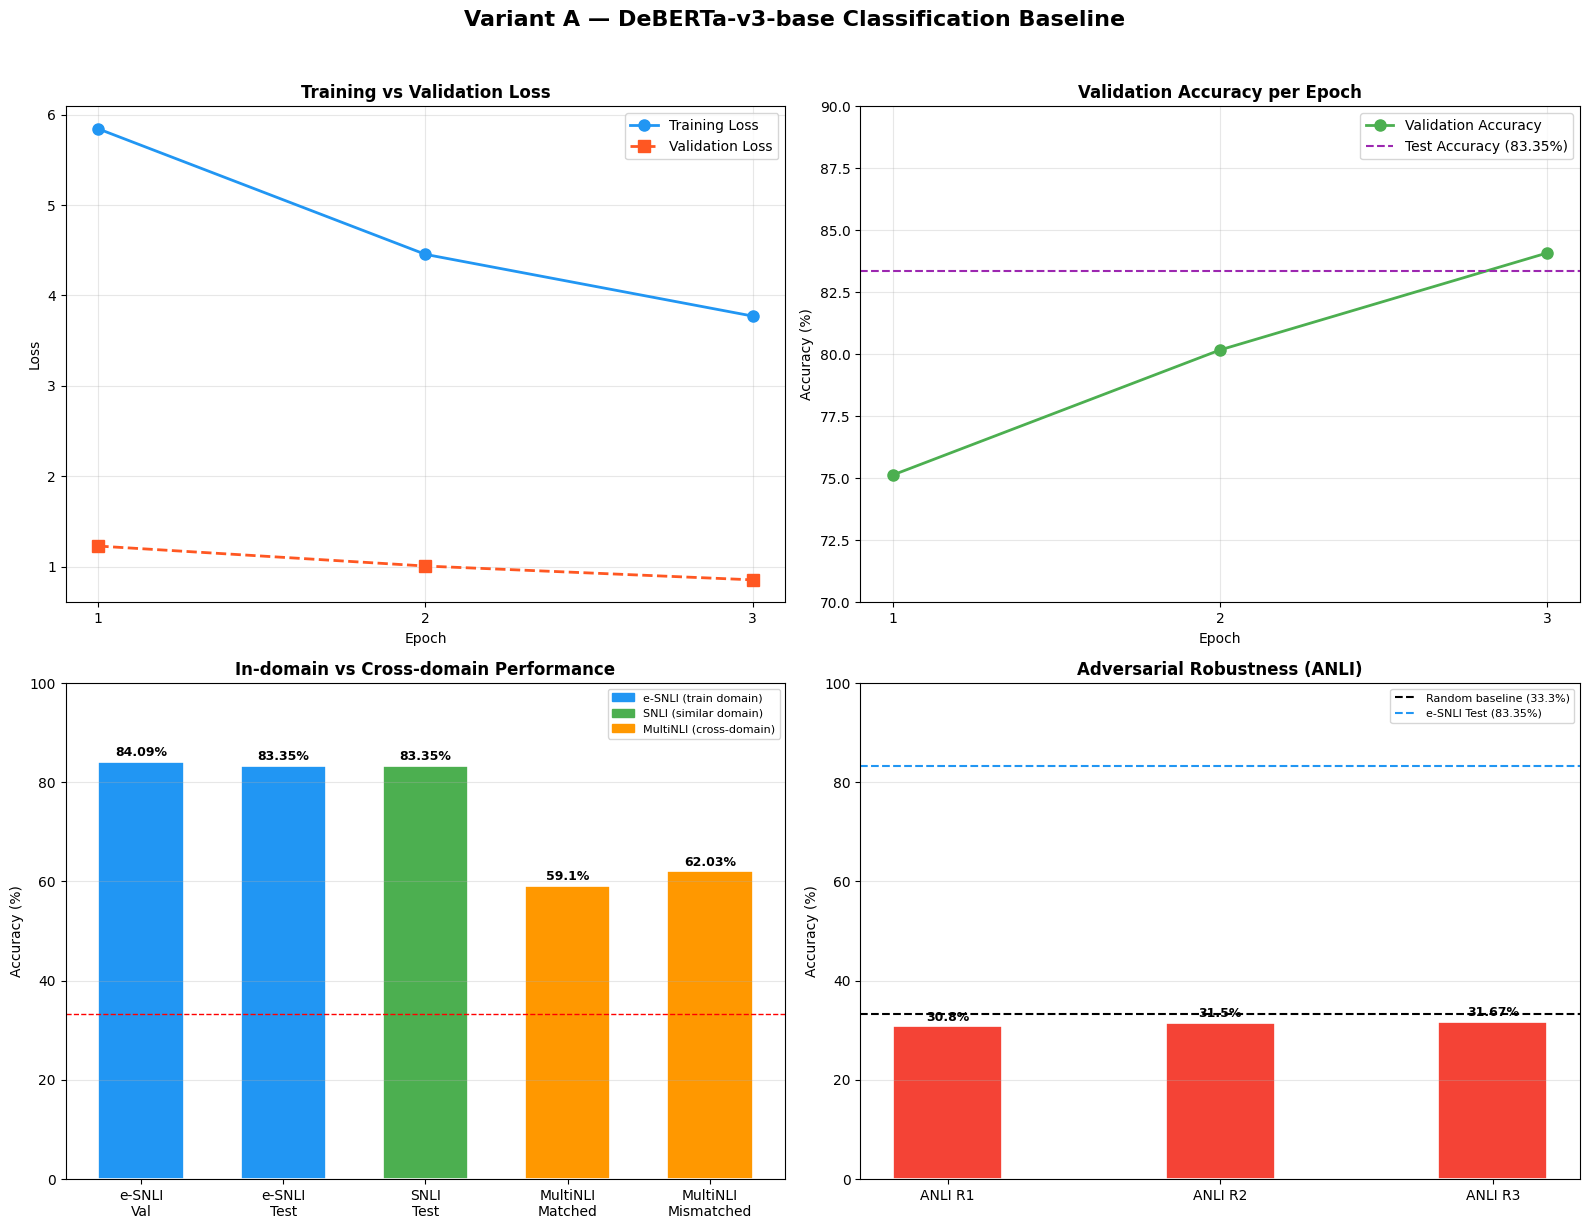

In [ ]:
# Evaluation plots
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

epochs     = [1, 2, 3]
train_loss = [5.8429, 4.4547, 3.7724]
val_loss   = [1.2281, 1.0072, 0.8544]
val_acc    = [75.14, 80.18, 84.09]

# Cross-domain values
snli_test_acc = 83.35
mnli_matched  = 59.10
mnli_mismatched = 62.03
anli_r1 = 30.80
anli_r2 = 31.50
anli_r3 = 31.67

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Variant A — DeBERTa-v3-base Classification Baseline",
             fontsize=16, fontweight='bold', y=1.02)

# Plot 1: Loss curves
axes[0,0].plot(epochs, train_loss, 'o-', color='#2196F3', linewidth=2,
                markersize=8, label='Training Loss')
axes[0,0].plot(epochs, val_loss, 's--', color='#FF5722', linewidth=2,
                markersize=8, label='Validation Loss')
axes[0,0].set_title('Training vs Validation Loss', fontweight='bold')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Loss')
axes[0,0].set_xticks(epochs)
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Accuracy curve
axes[0,1].plot(epochs, val_acc, 'o-', color='#4CAF50', linewidth=2,
                markersize=8, label='Validation Accuracy')
axes[0,1].axhline(y=snli_test_acc, color='#9C27B0', linestyle='--', linewidth=1.5,
                  label=f'Test Accuracy ({snli_test_acc}%)')
axes[0,1].set_title('Validation Accuracy per Epoch', fontweight='bold')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Accuracy (%)')
axes[0,1].set_xticks(epochs)
axes[0,1].set_ylim(70, 90)
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Plot 3: In-domain vs Cross-domain
benchmarks1 = ['e-SNLI\nVal', 'e-SNLI\nTest', 'SNLI\nTest',
                'MultiNLI\nMatched', 'MultiNLI\nMismatched']
# Updated accuracies here
accuracies1  = [84.09, snli_test_acc, snli_test_acc, mnli_matched, mnli_mismatched]
colors1      = ['#2196F3', '#2196F3', '#4CAF50', '#FF9800', '#FF9800']

bars1 = axes[1,0].bar(benchmarks1, accuracies1, color=colors1,
                      edgecolor='white', linewidth=1.2, width=0.6)
axes[1,0].set_title('In-domain vs Cross-domain Performance', fontweight='bold')
axes[1,0].set_ylabel('Accuracy (%)')
axes[1,0].set_ylim(0, 100)
axes[1,0].axhline(y=33.33, color='red', linestyle='--', linewidth=1,
                  label='Random baseline (33.3%)')
axes[1,0].grid(True, alpha=0.3, axis='y')

blue_patch   = mpatches.Patch(color='#2196F3', label='e-SNLI (train domain)')
green_patch = mpatches.Patch(color='#4CAF50', label='SNLI (similar domain)')
orange_patch = mpatches.Patch(color='#FF9800', label='MultiNLI (cross-domain)')
axes[1,0].legend(handles=[blue_patch, green_patch, orange_patch], fontsize=8)

# Plot 4: Adversarial performance
benchmarks2 = ['ANLI R1', 'ANLI R2', 'ANLI R3']
# Updated accuracies here
accuracies2  = [anli_r1, anli_r2, anli_r3]

bars2 = axes[1,1].bar(benchmarks2, accuracies2, color='#F44336',
                      edgecolor='white', linewidth=1.2, width=0.4)
axes[1,1].axhline(y=33.33, color='black', linestyle='--', linewidth=1.5,
                  label='Random baseline (33.3%)')
axes[1,1].axhline(y=snli_test_acc, color='#2196F3', linestyle='--', linewidth=1.5,
                  label=f'e-SNLI Test ({snli_test_acc}%)')
axes[1,1].set_title('Adversarial Robustness (ANLI)', fontweight='bold')
axes[1,1].set_ylabel('Accuracy (%)')
axes[1,1].set_ylim(0, 100)
axes[1,1].legend(fontsize=8)
axes[1,1].grid(True, alpha=0.3, axis='y')

# Add text labels on top of bars for all plots
for ax in [axes[1,0], axes[1,1]]:
    for bar in ax.patches:
        if bar.get_height() > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{bar.get_height()}%', ha='center', va='bottom', 
                    fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/variant_a_plots.png', dpi=150, bbox_inches='tight')
plt.show()